In [1]:
import sys
from pathlib import Path
import os 
import torch
import pandas as pd
import json
# Get the root directory (one level up from /notebooks)

sys.path.append("/home/llan/projects/messm/pytorch_geometric-single-read/graphgym/")
os.chdir("/home/llan/projects/messm/pytorch_geometric-single-read/graphgym")

import custom_graphgym  # noqa
import matplotlib.pyplot as plt
import seaborn as sns
from custom_graphgym.loader.normalization import (
    denorm_ihs,
    denorm_log1p,
    denorm_minmax,
    denorm_zscore,
)
from custom_graphgym.loader.graph_dataset import load_earne_dataset

from custom_graphgym.loader.graph_dataset import EARNeGraphDataset
from torch_geometric.graphgym.config import cfg, load_cfg, set_cfg
from torch_geometric.graphgym.loader import create_loader
from torch_geometric.graphgym.model_builder import create_model
from torch_geometric.graphgym.train import GraphGymDataModule, train
import argparse
import lightning as L
%load_ext autoreload
%autoreload 2

/home/llan/projects/messm/pytorch_geometric-single-read/graphgym/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

def _load_norm_params():
    e = cfg.earne_data.energy_norm_mode
    w = cfg.earne_data.weather_norm_mode
    g = cfg.earne_data.graph_mode
    path = Path(cfg.dataset.dir) / f"norm_params_{e}_{w}_{g}.pt"
    raw = torch.load(path, weights_only=False)
    return raw


def init_graphgym_config(config_path, opts=None):
    """Initializes the global GraphGym configuration."""
    cfg.set_new_allowed(True)
    set_cfg(cfg)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    
    # Create a mock args object to satisfy load_cfg requirements
    args = argparse.Namespace()
    args.cfg_file = config_path
    args.accelerator = device
    args.opts = opts if opts else []
    
    load_cfg(cfg, args)
    return cfg

def find_stats(exp_path, split="val"):
    records = []
    for file in Path(exp_path).glob(f"**/{split}/stats.json"):
        with open(file) as f:
            for line in f:
                record = json.loads(line)
                record["exp"] = file.parts[-4]  # e.g. earne_exp3-weather_mode=False-mp=3
                record["split"] = split
                records.append(record)
    return pd.DataFrame(records)    

denorm_dict = {
   "ihs" : denorm_ihs,
    "log1p": denorm_log1p,
    "minmax": denorm_minmax,
    "zscore": denorm_zscore,
}

In [3]:
# run the simulation here
import numpy as np
def collect_results(model, test_loader, params, load_denorm, pv_denorm):
    """Run model inference and denormalise predictions."""
    net_demand, actual_load, actual_pv, pred_load, pred_pv, mask = [], [], [], [], [], []
    n_q = cfg.model.n_quantiles
    
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            batch.to("cuda")
            pred, _ = model(batch)
            
            # Store data
            net_demand.append(batch.y_net_demand.cpu().numpy())
            actual_load.append(batch.y_load.cpu().numpy())
            actual_pv.append(batch.y_pv.cpu().numpy())
            pred_load.append(pred[:, :n_q].cpu().numpy())
            pred_pv.append(pred[:, n_q : 2 * n_q].cpu().numpy())
            mask.append(batch.mask.cpu().numpy())

    # Aggregate results
    res = {
        "net_demand": np.concatenate(net_demand, axis=0),
        "actual_load": np.concatenate(actual_load, axis=0),
        "actual_pv": np.concatenate(actual_pv, axis=0),
        "pred_load": np.concatenate(pred_load, axis=0),
        "pred_pv": np.concatenate(pred_pv, axis=0),
    }
    mask = np.concatenate(mask, axis=0).astype(bool)

    res["net_demand"] = denorm_ihs(torch.tensor(res["net_demand"], dtype=torch.float), params["net_scaled"][0], params["net_scaled"][1]).numpy()
    res["actual_load"] = load_denorm(torch.tensor(res["actual_load"], dtype=torch.float), params["load_scaled"][0], params["load_scaled"][1]).numpy()
    res["pred_load"] = load_denorm(torch.tensor(res["pred_load"], dtype=torch.float), params["load_scaled"][0], params["load_scaled"][1]).numpy()
    res["actual_pv"] = pv_denorm(torch.tensor(res["actual_pv"], dtype=torch.float), params["pv_scaled"][0], params["pv_scaled"][1]).numpy()
    res["pred_pv"] = pv_denorm(torch.tensor(res["pred_pv"], dtype=torch.float), params["pv_scaled"][0], params["pv_scaled"][1]).numpy()
    return res, mask
    


In [4]:
def rmse(true_array, pred_array, mask_bool_array):
    t = np.asarray(true_array)[mask_bool_array]
    p = np.asarray(pred_array)[mask_bool_array]
    return np.sqrt(np.mean((p - t) ** 2))


def nrmse(true_array, pred_array, mask_bool_array):
    t = np.asarray(true_array)[mask_bool_array]
    p = np.asarray(pred_array)[mask_bool_array]
    mean_obs = np.mean(t)
    return np.sqrt(np.mean((p - t) ** 2)) / mean_obs

def mae(true_array, pred_array, mask_bool_array):
    t = np.asarray(true_array)[mask_bool_array]
    p = np.asarray(pred_array)[mask_bool_array]
    s = np.abs(p-t)
    return np.mean(s) 

def mape(true_array, pred_array, mask_bool_array):
    t = np.asarray(true_array)[mask_bool_array]
    p = np.asarray(pred_array)[mask_bool_array]
    # exclude near-zero actuals to avoid division instability
    valid = np.abs(t) > 1e-10
    return np.mean(np.abs((p[valid] - t[valid]) / t[valid])) * 100


def r_squared(true_array, pred_array, mask_bool_array):
    t = np.asarray(true_array)[mask_bool_array]
    p = np.asarray(pred_array)[mask_bool_array]
    return np.corrcoef(p, t)[0, 1] ** 2


# --- pandas apply example ---

def compute_metrics(row):
    """Row-wise wrapper for use with df.apply(compute_metrics, axis=1)."""
    mask = row["mask"]
    return pd.Series({
        "RMSE":    rmse(row["true"], row["pred"], mask),
        "nRMSE":   nrmse(row["true"], row["pred"], mask),
        "MAE":     mae(row["true"], row["pred"], mask),
        "MAPE":    mape(row["true"], row["pred"], mask),
        "R2":      r_squared(row["true"], row["pred"], mask),
    })


rng = np.random.default_rng(0)
n = 100

df = pd.DataFrame({
    "true": [rng.normal(10, 2, n) for _ in range(3)],
    "pred": [rng.normal(10, 2, n) for _ in range(3)],
    "mask": [rng.choice([True, False], n, p=[0.8, 0.2]) for _ in range(3)],
})

metrics = df.apply(compute_metrics, axis=1)
print(metrics.round(4))

     RMSE   nRMSE     MAE     MAPE      R2
0  2.6979  0.2623  2.1345  22.0217  0.0001
1  2.8843  0.2931  2.4074  26.4989  0.0008
2  2.6033  0.2616  2.1267  21.6148  0.0272


In [67]:
# load the experiments here:
seed = 0

exp_path = Path("/home/llan/projects/messm/pytorch_geometric-single-read/graphgym/results/earne_exp3_grid_exp3")
exp_configs = list(exp_path.glob("**/config.yaml"))
# model_paths = list(exp_path.glob("**/*.ckpt"))
model_paths = [list(p.parent.joinpath(f"{str(seed)}/ckpt").glob("**/*.ckpt"))[-1] for p in exp_configs]
paired = list(zip(exp_configs, model_paths))

# load config
cfg = init_graphgym_config(exp_configs[-1])
cfg.accelerator = "cuda"

# load model
model = create_model()
ckpt = torch.load(model_paths[-1])
model.load_state_dict(ckpt["state_dict"])

# load normalization parameters
params =  _load_norm_params()
load_denorm_type, pv_denorm_type = cfg.earne_data.energy_norm_mode
load_denorm, pv_denorm = denorm_dict[load_denorm_type], denorm_dict[pv_denorm_type]

# load dataset
data = GraphGymDataModule.load_from_checkpoint(model_paths[-1])
test_loader = data.test_dataloader()
train_loader = data.train_dataloader() 

results, mask = collect_results(model, test_loader, params, load_denorm, pv_denorm)

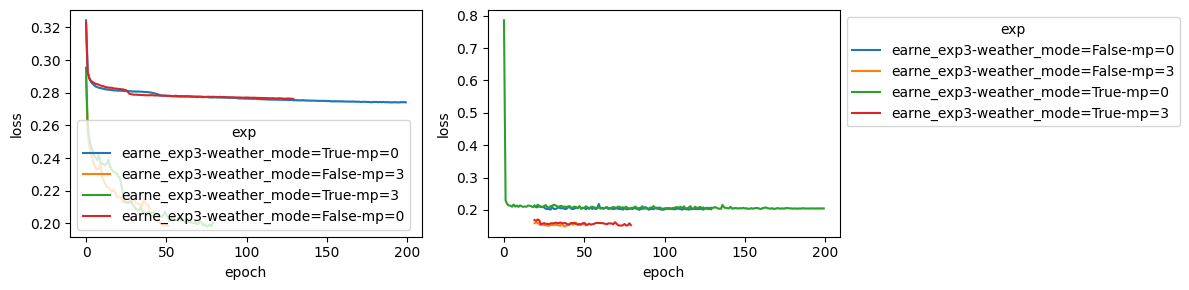

In [10]:
val_stats = find_stats(exp_path, "val")
train_stats = find_stats(exp_path, "train")

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
sns.lineplot(train_stats, x="epoch", y="loss", hue="exp", ax=ax[0], legend=True)
sns.lineplot(val_stats.groupby("exp").apply(lambda g: g.iloc[20:]).reset_index(), x="epoch", y="loss", hue="exp", ax=ax[1])
sns.move_legend(ax[1], loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

In [8]:
val_stats10101010101010

,epoch,loss,lr,params,time_iter,earne_mae_load,earne_mae_pv,exp,split,loss_std,lr_std,params_std,time_iter_std,earne_mae_load_std,earne_mae_pv_std
0,0,0.7858,0.0010,39734.0,0.9281,522.216221,597.572146,earne_exp3-weather_mode=True-mp=0,val,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0.2293,0.0010,39734.0,0.9293,434.063638,384.239638,earne_exp3-weather_mode=True-mp=0,val,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0.2295,0.0010,39734.0,0.9393,432.304462,434.470438,earne_exp3-weather_mode=True-mp=0,val,NaN,NaN,NaN,NaN,NaN,NaN
3,2,0.2176,0.0010,39734.0,0.9470,387.297884,334.004025,earne_exp3-weather_mode=True-mp=0,val,NaN,NaN,NaN,NaN,NaN,NaN
4,3,0.2137,0.0010,39734.0,0.9231,376.200291,328.649217,earne_exp3-weather_mode=True-mp=0,val,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
661,125,0.2034,0.0003,32838.0,0.7382,325.551492,261.363223,earne_exp3-weather_mode=False-mp=0,val,NaN,NaN,NaN,NaN,NaN,NaN
662,126,0.2070,0.0003,32838.0,0.7629,327.762451,290.881368,earne_exp3-weather_mode=False-mp=0,val,NaN,NaN,NaN,NaN,NaN,NaN
663,127,0.2028,0.0003,32838.0,0.7501,311.558906,256.905190,earne_exp3-weather_mode=False-mp=0,val,NaN,NaN,NaN,NaN,NaN,NaN
664,128,0.2035,0.0003,32838.0,0.7439,325.512873,263.553806,earne_exp3-weather_mode=False-mp=0,val,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
stats.groupby("exp")["loss"].min().reset_index()

,exp,loss
0,earne_exp3-weather_mode=False-mp=0,0.2005
1,earne_exp3-weather_mode=False-mp=3,0.1492
2,earne_exp3-weather_mode=True-mp=0,0.2076
3,earne_exp3-weather_mode=True-mp=3,0.1517


In [62]:
model_paths

[PosixPath('/home/llan/projects/messm/pytorch_geometric-single-read/graphgym/results/earne_exp3_grid_exp3/earne_exp3-weather_mode=False-mp=0/0/ckpt/epoch=129-step=522990.ckpt'),
 PosixPath('/home/llan/projects/messm/pytorch_geometric-single-read/graphgym/results/earne_exp3_grid_exp3/earne_exp3-weather_mode=True-mp=3/0/ckpt/epoch=79-step=321840.ckpt'),
 PosixPath('/home/llan/projects/messm/pytorch_geometric-single-read/graphgym/results/earne_exp3_grid_exp3/earne_exp3-weather_mode=False-mp=3/0/ckpt/epoch=51-step=209196.ckpt'),
 PosixPath('/home/llan/projects/messm/pytorch_geometric-single-read/graphgym/results/earne_exp3_grid_exp3/earne_exp3-weather_mode=True-mp=0/0/ckpt/epoch=199-step=804600.ckpt')]

In [66]:
model = create_model()
ckpt = torch.load(path)
model.load_state_dict(ckpt["state_dict"])

RuntimeError: Error(s) in loading state_dict for GraphGymModule:
	Missing key(s) in state_dict: "model.encoder.weather_encoder.0.weight", "model.encoder.weather_encoder.0.bias", "model.encoder.weather_encoder.2.weight", "model.encoder.weather_encoder.2.bias", "model.encoder.weather_encoder.6.weight", "model.encoder.weather_encoder.6.bias", "model.encoder.weather_gate.weight", "model.encoder.weather_gate.bias". 
	size mismatch for model.encoder.integration.0.weight: copying a param with shape torch.Size([64, 80]) from checkpoint, the shape in current model is torch.Size([64, 112]).

no weather encoder used
1
4704
1
no weather encoder used
1
4704
1


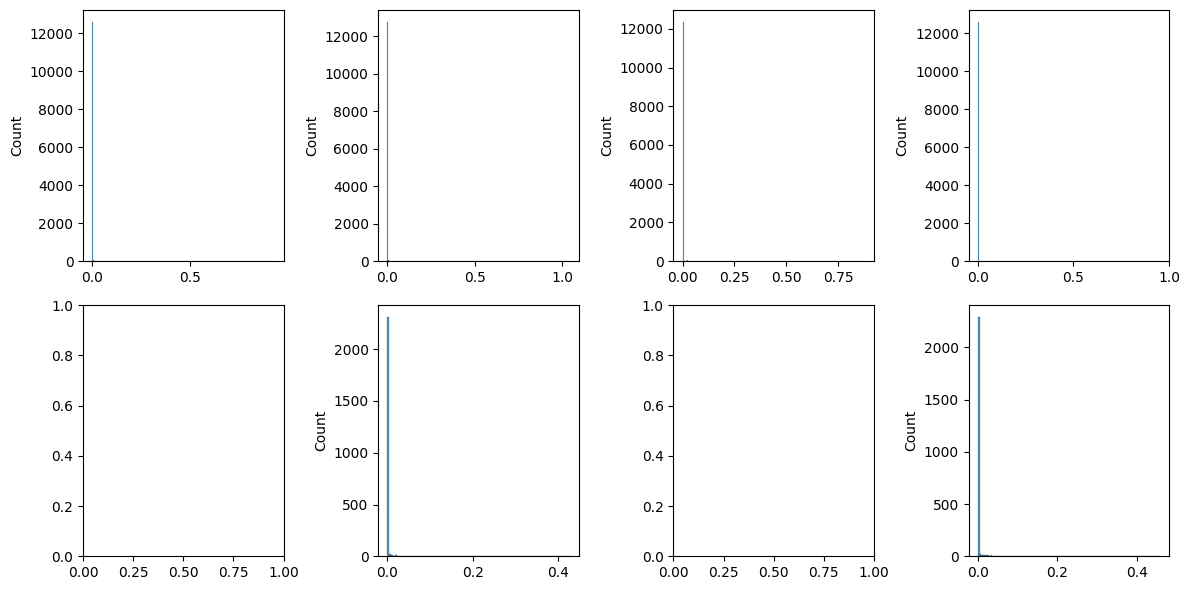

In [109]:
# checking weight distribution of models
fig, ax = plt.subplots(2, len(model_paths), figsize=(3 * len(model_paths), 6))
ep

for i, (conf, p) in enumerate(paired):
    # load model
    cfg = init_graphgym_config(conf)
    cfg.accelerator = "cuda"
    model = create_model()
    ckpt = torch.load(p)
    model.load_state_dict(ckpt["state_dict"])

    try:
        weather_weight = np.concat([val.flatten().cpu() for key, val in model.state_dict().items() if "weather" in key and "weight" in key])
        sns.histplot(weather_weight[weather_weight > eps], ax=ax[1, i])
        print(len(weather_weight < eps))
    except:
        print("no weather encoder used")
    net_weight = np.concat([val.flatten().cpu() for key, val in model.state_dict().items() if "net_encoder" in key and "weight" in key])
    sns.histplot(net_weight[net_weight > eps], ax=ax[0, i], bins=200)
    print(len(np.where(net_weight < eps)))
    
    

plt.tight_layout()

In [121]:
# checking weight distribution of models
eps = 1e-8

for i, (conf, p) in enumerate(paired):
    # load model
    cfg = init_graphgym_config(conf)
    cfg.accelerator = "cuda"
    model = create_model()
    ckpt = torch.load(p)
    model.load_state_dict(ckpt["state_dict"])
    print("####", p)
    agg_dead = 0
    n_param = 0
    
    for key, val in model.state_dict().items():
        absolute = val.flatten().cpu().abs()
        n_dead_weight = (absolute < eps).sum().item()
        agg_dead += n_dead_weight
        total_weight = absolute.numel()
        n_param += total_weight
        print(f"--- {key}: {(n_dead_weight/total_weight) * 100} [{n_dead_weight}]")
        print()
    print(f"TOTAL: {agg_dead/n_param * 100} [{agg_dead}]")
    print()
    
        
        


#### /home/llan/projects/messm/pytorch_geometric-single-read/graphgym/results/earne_exp3_grid_exp3/earne_exp3-weather_mode=False-mp=0/0/ckpt/epoch=129-step=522990.ckpt
--- model.encoder.net_encoder.0.weight: 0.0 [0]

--- model.encoder.net_encoder.0.bias: 0.0 [0]

--- model.encoder.net_encoder.2.weight: 17.903645833333336 [550]

--- model.encoder.net_encoder.2.bias: 0.0 [0]

--- model.encoder.net_encoder.4.weight: 0.1953125 [12]

--- model.encoder.net_encoder.4.bias: 0.0 [0]

--- model.encoder.net_encoder.6.weight: 0.016276041666666664 [2]

--- model.encoder.net_encoder.6.bias: 0.0 [0]

--- model.encoder.net_encoder.10.weight: 0.0 [0]

--- model.encoder.net_encoder.10.bias: 0.0 [0]

--- model.encoder.time_encoder.0.weight: 0.0 [0]

--- model.encoder.time_encoder.0.bias: 0.0 [0]

--- model.encoder.time_encoder.2.weight: 0.0 [0]

--- model.encoder.time_encoder.2.bias: 0.0 [0]

--- model.encoder.integration.0.weight: 0.0 [0]

--- model.encoder.integration.0.bias: 0.0 [0]

--- model.encoder

In [107]:
np.where(weather_weight < 10e-7)

ValueError: either both or neither of x and y should be given

In [105]:
np.abs(weather_weight).min()
np.abs(net_weight).min()

np.float32(3.1678359e-15)

1e-100

In [42]:
weather_weight = np.concat([val.flatten().cpu() for key, val in model.state_dict().items() if "weather" in key and "weight" in key])
net_weight = np.concat([val.flatten().cpu() for key, val in model.state_dict().items() if "net_encoder" in key and "weight" in key])

<Axes: ylabel='Density'>

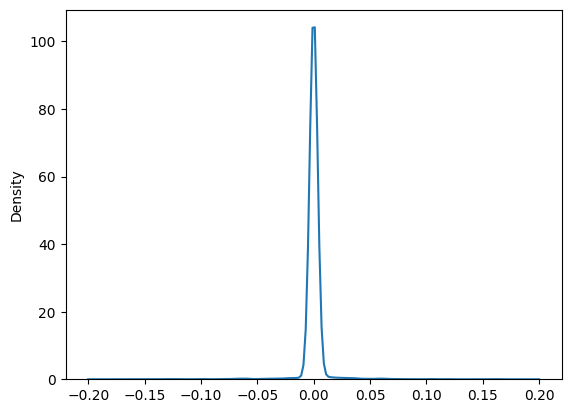

In [46]:
sns.kdeplot(weather_weight, clip=(-0.2, 0.2))

<Axes: ylabel='Density'>

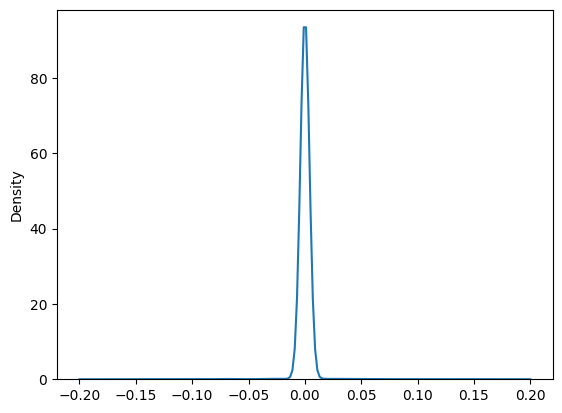

In [47]:
sns.kdeplot(net_weight, clip=(-0.2, 0.2))

In [ ]:
iradiance, cloud cover, temp

In [20]:
results

{'net_demand': array([  0.     ,   0.     , 239.86282, ...,   0.     ,   0.     ,
          0.     ], shape=(2977896,), dtype=float32),
 'actual_load': array([  0.     ,   0.     , 239.86273, ...,   0.     ,   0.     ,
          0.     ], shape=(2977896,), dtype=float32),
 'actual_pv': array([0., 0., 0., ..., 0., 0., 0.], shape=(2977896,), dtype=float32),
 'pred_load': array([[-8.6190537e-02,  8.1088954e-01,  1.3749857e+01],
        [-8.4474728e-02,  8.9265114e-01,  1.3582427e+01],
        [-1.1092669e-02,  1.9090152e+02,  2.6668781e+02],
        ...,
        [ 9.1758318e-02,  4.8044902e-01,  8.9376213e+01],
        [ 4.5173869e-02,  1.9727123e+01,  1.1233404e+02],
        [ 5.9286673e-02,  1.0258557e+01,  1.0837202e+02]],
       shape=(2977896, 3), dtype=float32),
 'pred_pv': array([[-2.1201054e-02,  6.7638606e-02,  1.3358550e-01],
        [-2.1134280e-02,  6.9237120e-02,  1.3383639e-01],
        [-1.7156489e-02, -7.5746309e-03, -1.3542180e-03],
        ...,
        [-9.1019934e-03,  

In [77]:
# get metrics for grid experiment
metrics = []
for i in range(len(exp_configs)):
    exp_name = exp_configs[i].parts[-2]
    print(exp_name)
    # load config
    cfg = init_graphgym_config(exp_configs[i])
    cfg.accelerator = "cuda"
    
    # load model
    model = create_model()
    ckpt = torch.load(model_paths[i])
    model.load_state_dict(ckpt["state_dict"])Dag Edwin,

Tijdens onze laatste maandelijkse MESSM-meeting kwam naar voren dat DSO’s actief bezig zijn met de detectie van achter-de-meter batterijsystemen. 
Omdat dit thema nauw verwant is aan het MESSM-project, hebben Tarek en ik besloten om hierop in te haken door een promotievoorstel over dit onderwerp te schrijven.

Zou jij tijd hebben om in het kader hiervan en het MESSM-project een meeting te plannen? We zouden dan:

    De huidige progressie binnen MESSM doornemen en verdere interesses vanuit Be-Next afstemmen;


    In brede zin van gedachten wisselen over de adoptie van batterijsystemen, smart home-integraties en de rol van ISP's hierin.


Mocht je hiervoor openstaan, dan kunnen we dit eventueel on-site bij jullie op kantoor doen. Ik hoor het graag.

Groetjes,

Llan Almendariz
    
    # load normalization parameters
    params =  _load_norm_params()
    load_denorm_type, pv_denorm_type = cfg.earne_data.energy_norm_mode
    load_denorm, pv_denorm = denorm_dict[load_denorm_type], denorm_dict[pv_denorm_type]

    # load dataset
    data = GraphGymDataModule.load_from_checkpoint(model_paths[i])
    test_loader = data.test_dataloader()
    train_loader = data.train_dataloader() 

    # collect results 
    results, mask = collect_results(model, test_loader, params, load_denorm, pv_denorm)
    
    df = pd.DataFrame({
        "true": [results["actual_pv"], results["actual_load"]],
        "pred": [results["pred_pv"][:, 1], results["pred_load"][:, 1]],
        "mask": [mask, mask],
    })
    m = df.apply(compute_metrics, axis=1)
    m.index = ["pv", "load"]
    m["model"] = exp_name
    metrics.append(m)
    print(m)

earne_exp3-weather_mode=False-mp=0
            RMSE     nRMSE         MAE        MAPE        R2  \
pv    699.492188  1.306766  226.302994  44960752.0  0.813629   
load  940.572510  0.921881  357.618011  63144712.0  0.650401   

                                   model  
pv    earne_exp3-weather_mode=False-mp=0  
load  earne_exp3-weather_mode=False-mp=0  
earne_exp3-weather_mode=True-mp=3
             RMSE     nRMSE         MAE        MAPE        R2  \
pv    1020.396606  1.906269  272.634827  39325208.0  0.620348   
load  1360.350098  1.333317  409.656647  68371296.0  0.424594   

                                  model  
pv    earne_exp3-weather_mode=True-mp=3  
load  earne_exp3-weather_mode=True-mp=3  
earne_exp3-weather_mode=False-mp=3
             RMSE     nRMSE         MAE        MAPE        R2  \
pv     804.758972  1.503422  232.152130  62453180.0  0.747653   
load  1222.578247  1.198283  391.869293  61264200.0  0.504098   

                                   model  
pv    earne_e

FileNotFoundError: [Errno 2] No such file or directory: '/home/llan/projects/messm/pytorch_geometric-single-read/graphgym/results/earne_exp3_grid_exp3/earne_exp3-weather_mode=True-mp=0/0/ckpt/epoch=36-step=148851.ckpt'

In [101]:
exp_configs[0].parts[-2]

'earne_exp2-weather_mode=True-mp=0-graph_mode=full_graph-norm_mode=ihs'

In [118]:
grid_conc = pd.concat(metrics).reset_index(names="load_type")
grid_conc = grid_conc.set_index(["model", "load_type"])

In [121]:
grid_conc.sort_values(["R2"]).to_clipboard()

In [18]:
earne_exp2-weather_mode=True-mp=2-graph_mode=full_graph-norm_mode=log1p

1728

In [14]:
test_loader.dataset[1]

Data(x=[54, 96, 1], edge_index=[2, 270], y=[54, 4], pos=[54, 2], weather=[54, 14], macs=[54], zips=[54], y_load=[54], y_pv=[54], y_net_demand=[54], mask=[54], num_nodes=54, timestamp=2024-10-17 01:30:00+00:00)

In [43]:
# run the simulation here
import numpy as np
def collect_results(model, test_loader, denorm_params):
    """Run model inference and denormalise predictions."""
    net_demand, actual_load, actual_pv, pred_load, pred_pv, mask = [], [], [], [], [], []
    n_q = cfg.model.n_quantiles
    
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            batch.to("cuda")
            pred, _ = model(batch)
            
            # Store data
            net_demand.append(batch.y_net_demand.cpu().numpy())
            actual_load.append(batch.y_load.cpu().numpy())
            actual_pv.append(batch.y_pv.cpu().numpy())
            pred_load.append(pred[:, :n_q].cpu().numpy())
            pred_pv.append(pred[:, n_q : 2 * n_q].cpu().numpy())
            mask.append(batch.mask.cpu().numpy())

    # Aggregate results
    res = {
        "net_demand": np.concatenate(net_demand, axis=0),
        "actual_load": np.concatenate(actual_load, axis=0),
        "actual_pv": np.concatenate(actual_pv, axis=0),
        "pred_load": np.concatenate(pred_load, axis=0),
        "pred_pv": np.concatenate(pred_pv, axis=0),
    }
    mask = np.concatenate(mask, axis=0).astype(bool)

    res["net_demand"] = denorm_fn(torch.tensor(res["net_demand"], dtype=torch.float), params["net_scaled"][0], params["net_scaled"][1]).numpy()
    res["actual_load"] = denorm_fn(torch.tensor(res["actual_load"], dtype=torch.float), params["load_scaled"][0], params["load_scaled"][1]).numpy()
    res["pred_load"] = denorm_fn(torch.tensor(res["pred_load"], dtype=torch.float), params["load_scaled"][0], params["load_scaled"][1]).numpy()
    res["actual_pv"] = denorm_fn(torch.tensor(res["actual_pv"], dtype=torch.float), params["pv_scaled"][0], params["pv_scaled"][1]).numpy()
    res["pred_pv"] = denorm_fn(torch.tensor(res["pred_pv"], dtype=torch.float), params["pv_scaled"][0], params["pv_scaled"][1]).numpy()
    return res, mask
    
results, mask = collect_results(model, test_loader, (p1, p2, denorm_fn))

In [85]:
np.unique(mask, return_counts=True)

(array([False,  True]), array([  91826, 2886070]))

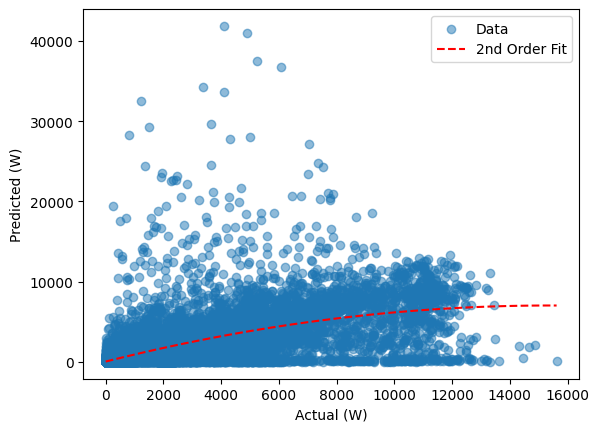

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_regression_fit(true, pred):
    """Scatterplot with a 2nd order polynomial fit."""
    plt.scatter(true, pred, alpha=0.5, label='Data')
    
    # 2nd order polynomial fit
    z = np.polyfit(true, pred, 2)
    p = np.poly1d(z)
    x_range = np.linspace(true.min(), true.max(), 100)
    
    plt.plot(x_range, p(x_range), "r--", label='2nd Order Fit')
    plt.xlabel('Actual (W)'); plt.ylabel('Predicted (W)')
    plt.legend()
    plt.show()


plot_regression_fit(results["actual_load"][mask][:100_000], results["pred_load"][mask, 1][:100_000])

In [79]:
def plot_residuals(true, pred):
    """Residual plot with 2nd order fit and density distribution."""
    residuals = pred - true
    
    # Jointplot handles the scatter and the marginal density automatically
    g = sns.jointplot(x=true, y=residuals, kind='scatter', alpha=0.5)
    
    # Add 2nd order fit to the joint ax
    z = np.polyfit(true, residuals, 2)
    p = np.poly1d(z)
    x_range = np.linspace(true.min(), true.max(), 100)
    g.ax_joint.plot(x_range, p(x_range), "r--")
    
    # Zero line
    g.ax_joint.axhline(0, color='black', lw=2)
    
    g.set_axis_labels('Actual (W)', 'Residuals (W)')
    plt.show()

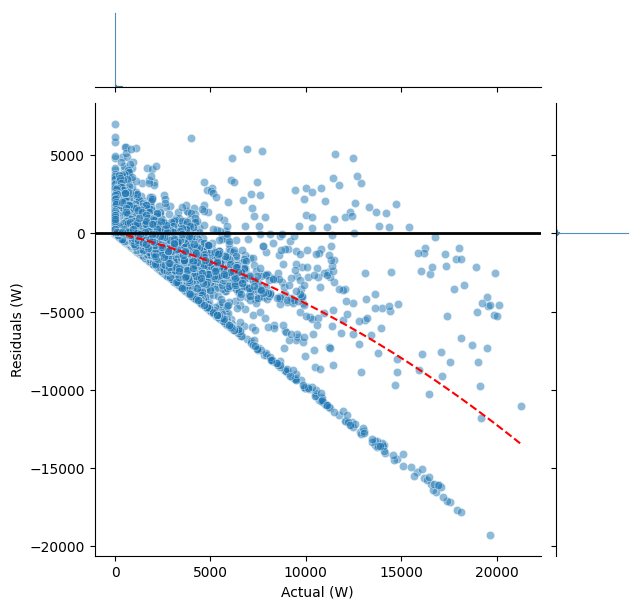

In [82]:
plot_residuals(results["actual_pv"][mask][:100_000], results["pred_pv"][mask][:100_000, 1])

In [82]:
def rmse(true_array, pred_array, mask_bool_array):
    t = np.asarray(true_array)[mask_bool_array]
    p = np.asarray(pred_array)[mask_bool_array]
    return np.sqrt(np.mean((p - t) ** 2))


def nrmse(true_array, pred_array, mask_bool_array):
    t = np.asarray(true_array)[mask_bool_array]
    p = np.asarray(pred_array)[mask_bool_array]
    mean_obs = np.mean(t)
    return np.sqrt(np.mean((p - t) ** 2)) / mean_obs

def mae(true_array, pred_array, mask_bool_array):
    t = np.asarray(true_array)[mask_bool_array]
    p = np.asarray(pred_array)[mask_bool_array]
    s = np.abs(p-t)
    return np.mean(s) 

def mape(true_array, pred_array, mask_bool_array):
    t = np.asarray(true_array)[mask_bool_array]
    p = np.asarray(pred_array)[mask_bool_array]
    # exclude near-zero actuals to avoid division instability
    valid = np.abs(t) > 1e-10
    return np.mean(np.abs((p[valid] - t[valid]) / t[valid])) * 100


def r_squared(true_array, pred_array, mask_bool_array):
    t = np.asarray(true_array)[mask_bool_array]
    p = np.asarray(pred_array)[mask_bool_array]
    return np.corrcoef(p, t)[0, 1] ** 2


# --- pandas apply example ---

def compute_metrics(row):
    """Row-wise wrapper for use with df.apply(compute_metrics, axis=1)."""
    mask = row["mask"]
    return pd.Series({
        "RMSE":    rmse(row["true"], row["pred"], mask),
        "nRMSE":   nrmse(row["true"], row["pred"], mask),
        "MAE":     mae(row["true"], row["pred"], mask),
        "MAPE":    mape(row["true"], row["pred"], mask),
        "R2":      r_squared(row["true"], row["pred"], mask),
    })


rng = np.random.default_rng(0)
n = 100

df = pd.DataFrame({
    "true": [rng.normal(10, 2, n) for _ in range(3)],
    "pred": [rng.normal(10, 2, n) for _ in range(3)],
    "mask": [rng.choice([True, False], n, p=[0.8, 0.2]) for _ in range(3)],
})

metrics = df.apply(compute_metrics, axis=1)
print(metrics.round(4))

     RMSE   nRMSE     MAE     MAPE      R2
0  2.6979  0.2623  2.1345  22.0217  0.0001
1  2.8843  0.2931  2.4074  26.4989  0.0008
2  2.6033  0.2616  2.1267  21.6148  0.0272


In [84]:
results["pred_pv"][:, 1]

array([ 7.6310183e-03, -3.6835670e-05, -4.6968460e-05, ...,
        7.3480389e+02,  9.7307153e+02,  6.0545508e+02],
      shape=(1266192,), dtype=float32)

In [85]:
results["actual_pv"]

array([0., 0., 0., ..., 0., 0., 0.], shape=(1266192,), dtype=float32)

In [86]:
df = pd.DataFrame({
    "true": [results["actual_pv"], results["actual_load"]],
    "pred": [results["pred_pv"][:, 1], results["pred_load"][:, 1]],
    "mask": [mask, mask],
})

In [87]:
df

,true,pred,mask
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0076310183, -3.683567e-05, -4.696846e-05, -...","[False, True, True, True, True, True, True, Tr..."
1,"[0.0, 200.3484, 500.83066, 141.61641, 283.7578...","[0.0031960064, 178.18723, 315.88196, 116.12867...","[False, True, True, True, True, True, True, Tr..."


In [88]:
metrics = df.apply(compute_metrics, axis=1)

In [89]:
metrics

,RMSE,nRMSE,MAE,MAPE,R2
0,672.864197,1.400266,233.414200,56424488.0,0.684814
1,1190.616943,1.185607,543.683472,30260776.0,0.336656


In [31]:
pd.DataFrame(results["net_demand"]).describe()

,0
count,1.266192e+06
mean,4.434142e+02
std,1.789809e+03
min,-1.843909e+04
25%,-1.192093e-07
50%,3.378637e+02
75%,9.613234e+02
max,1.988255e+04


In [231]:
train_loader.dataset.data is test_loader.dataset.data

True

In [232]:
# Assuming your dataset returns (x, y) or a batch object
def retrieve_data(loader):
    all_x = torch.stack([loader.dataset[i].x for i in range(len(loader.dataset))])
    return all_x

In [233]:
train_data = retrieve_data(train_loader)

In [234]:
train_data = denorm_fn(train_data[..., -1, :].flatten(), p1, p2)

In [235]:
pd.DataFrame(train_data.numpy()).describe()

,0
count,6.951474e+06
mean,1.855937e+02
std,1.508863e+03
min,-2.104479e+04
25%,0.000000e+00
50%,0.000000e+00
75%,3.781589e+02
max,2.058243e+04


In [236]:
test_data = retrieve_data(test_loader)

In [237]:
test_data = denorm_fn(test_data[..., -1, :].flatten(), p1, p2)

In [238]:
pd.DataFrame(test_data.numpy()).describe()

,0
count,1.266192e+06
mean,4.434381e+02
std,1.789811e+03
min,-1.843909e+04
25%,0.000000e+00
50%,3.378827e+02
75%,9.613358e+02
max,1.988255e+04
